In [10]:
import os
import pandas as pd
import numpy as np
path = os.path.join( "..", "data", "processed", "risk_preprocessed.csv")
df = pd.read_csv(path)

/var/folders/05/_vxzr9653lg058wd1tp1rdyr0000gn/T/ipykernel_35315/2176521094.py:5: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


/var/folders/05/_vxzr9653lg058wd1tp1rdyr0000gn/T/ipykernel_35315/348542129.py:22: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/opt/anaconda3/envs/accidents/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

           1       0.39      0.31      0.35     12350
           2       0.33      0.61      0.42     12349
           3       0.30      0.13      0.18     12349
           4       0.34      0.25      0.29     12349
           5       0.36      0.40      0.38     12350

    accuracy                           0.34     61747
   macro avg       0.34      0.34      0.32     61747
weighted avg       0.34      0.34      0.32     61747



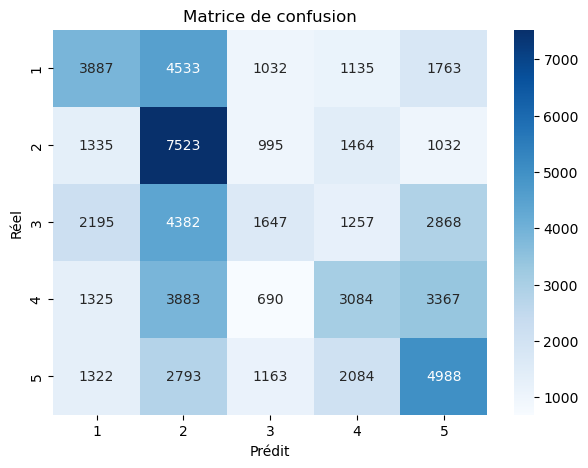

In [ ]:
##############
# Logistic Regression
##############
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline  # Pour compatibilité SMOTETomek
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Importation des données

path = os.path.join( "..", "data", "processed", "risk_preprocessed.csv")
df = pd.read_csv(path)

# === 1. Split data
X = df.drop(columns=['risk_class'])  
y = df['risk_class']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)




# Colonnes
cols_to_exclude = ['dep'] 
cols_to_ohe = [col for col in X_train.columns if col not in cols_to_exclude]

# Préprocesseur combiné
preprocessor = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_ohe),
    ('target_enc', TargetEncoder(), ['dep'])
], remainder='passthrough')



pipeline = ImbPipeline(steps=[
    ('encoding', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, multi_class='multinomial'))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)


print(classification_report(y_test, y_pred))


# --- Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
classes = sorted(y.unique())  
# --- Affichage
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()

              precision    recall  f1-score   support

           1       0.44      0.59      0.50     12350
           2       0.49      0.72      0.58     12349
           3       0.33      0.16      0.21     12349
           4       0.36      0.27      0.31     12349
           5       0.38      0.38      0.38     12350

    accuracy                           0.42     61747
   macro avg       0.40      0.42      0.40     61747
weighted avg       0.40      0.42      0.40     61747



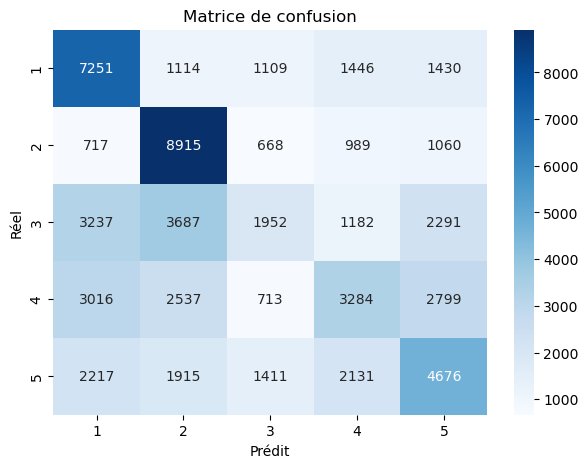

In [27]:
##############
# Random Forest 
##############
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


# Importation des données

path = os.path.join( "..", "data", "processed", "risk_preprocessed.csv")
df = pd.read_csv(path)

# === 1. Split data
X = df.drop(columns=['risk_class'])  
y = df['risk_class']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)




# Colonnes
cols_to_exclude = ['dep'] 
cols_to_ohe = [col for col in X_train.columns if col not in cols_to_exclude]

# Préprocesseur combiné
preprocessor = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_ohe),
    ('target_enc', TargetEncoder(), ['dep'])
], remainder='passthrough')



pipeline = ImbPipeline(steps=[
    ('encoding', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)


print(classification_report(y_test, y_pred))


# --- Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
classes = sorted(y.unique())  
# --- Affichage
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()

/var/folders/05/_vxzr9653lg058wd1tp1rdyr0000gn/T/ipykernel_35315/2639156857.py:24: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/opt/anaconda3/envs/accidents/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [17:10:29] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_abwcuua5oq/croot/xgboost-split_1749630928197/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.45      0.62      0.52     12350
           1       0.49      0.75      0.60     12349
           2       0.38      0.15      0.22     12349
           3       0.39      0.26      0.31     12349
           4       0.39      0.41      0.40     12350

    accuracy                           0.44     61747
   macro avg       0.42      0.44      0.41     61747
weighted avg       0.42      0.44      0.41     61747



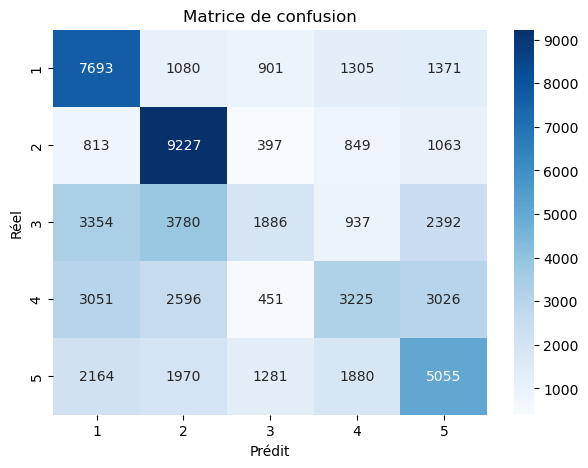

In [13]:
##############
# XGBoost 
##############
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline  # Pour compatibilité SMOTETomek
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder


# Importation des données

path = os.path.join( "..", "data", "processed", "risk_preprocessed.csv")
df = pd.read_csv(path)

# === 1. Split data
X = df.drop(columns=['risk_class'])  
y = df['risk_class']

le = LabelEncoder()
y_encoded = le.fit_transform(y)  # y = [1, 2, 3, 4, 5] ➜ y_encoded = [0, 1, 2, 3, 4]

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, stratify=y, random_state=42)




# Colonnes
cols_to_exclude = ['dep'] 
cols_to_ohe = [col for col in X_train.columns if col not in cols_to_exclude]

# Préprocesseur combiné
preprocessor = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_ohe),
    ('target_enc', TargetEncoder(), ['dep'])
], remainder='passthrough')



pipeline = ImbPipeline(steps=[
    ('encoding', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42
    )) 
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)


print(classification_report(y_test, y_pred))


# --- Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
classes = sorted(y.unique())  
# --- Affichage
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()

Epoch 1/50
579/579 ━━━━━━━━━━━━━━━━━━━━ 1s 796us/step - accuracy: 0.3857 - loss: 1.4296 - val_accuracy: 0.4322 - val_loss: 1.3310
Epoch 2/50
579/579 ━━━━━━━━━━━━━━━━━━━━ 0s 709us/step - accuracy: 0.4379 - loss: 1.3234 - val_accuracy: 0.4380 - val_loss: 1.3288
Epoch 3/50
579/579 ━━━━━━━━━━━━━━━━━━━━ 0s 692us/step - accuracy: 0.4433 - loss: 1.3156 - val_accuracy: 0.4398 - val_loss: 1.3262
Epoch 4/50
579/579 ━━━━━━━━━━━━━━━━━━━━ 0s 700us/step - accuracy: 0.4467 - loss: 1.3102 - val_accuracy: 0.4391 - val_loss: 1.3245
Epoch 5/50
579/579 ━━━━━━━━━━━━━━━━━━━━ 0s 696us/step - accuracy: 0.4478 - loss: 1.3074 - val_accuracy: 0.4378 - val_loss: 1.3257
Epoch 6/50
579/579 ━━━━━━━━━━━━━━━━━━━━ 0s 707us/step - accuracy: 0.4478 - loss: 1.3034 - val_accuracy: 0.4350 - val_loss: 1.3256
Epoch 7/50
579/579 ━━━━━━━━━━━━━━━━━━━━ 0s 701us/step - accuracy: 0.4491 - loss: 1.3036 - val_accuracy: 0.4368 - val_loss: 1.3256
Epoch 8/50
579/579 ━━━━━━━━━━━━━━━━━━━━ 0s 704us/step - accuracy: 0.4527 - loss: 1.2981 - 

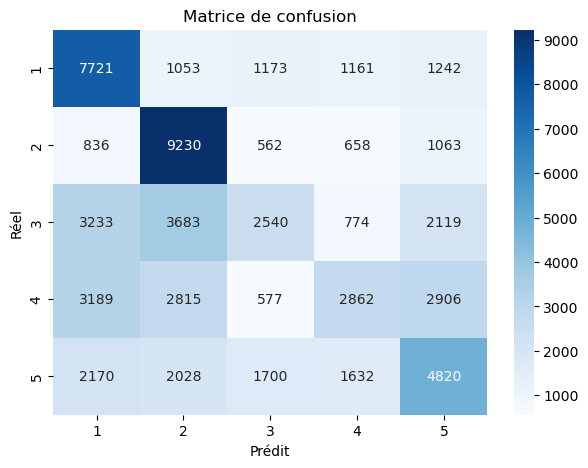

In [24]:
##################
# DNN 
##################

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping

# Importation des données

path = os.path.join( "..", "data", "processed", "risk_preprocessed.csv")
df = pd.read_csv(path)

# 0. Split
X = df.drop(columns=['risk_class'])
y = df['risk_class'].astype(str)     # si c'est déjà un str, pas grave
X = X.astype(str)                    # toutes les features en str

X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, random_state=42)

# 1. Encodage du y -> 0..4
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # ndarray int32
y_test_enc  = le.transform(y_test)

# 2. One-hot (dense pour Keras)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
preproc = ColumnTransformer([("ohe", ohe, X.columns)], remainder='drop')

X_train_proc = preproc.fit_transform(X_train).astype("float32")
X_test_proc  = preproc.transform(X_test).astype("float32")

# 3. DNN
input_dim = X_train_proc.shape[1]
model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dense(64, activation='relu'),
    Dense(len(le.classes_), activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. pondération des classes
cw = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.arange(len(le.classes_)),
        y=y_train_enc)
cw_dict = {i: w for i, w in enumerate(cw)}

# 5. entraînement
es = EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')
model.fit(X_train_proc, y_train_enc,
          epochs=50,
          batch_size=256,
          validation_split=0.2,
          class_weight=cw_dict,
          callbacks=[es],
          verbose=1)

# 6. évaluation
y_pred_enc = model.predict(X_test_proc).argmax(axis=1)
print(classification_report(le.inverse_transform(y_test_enc),
                            le.inverse_transform(y_pred_enc)))
##############



# --- Calcul de la matrice de confusion
cm = confusion_matrix(y_test_enc, y_pred_enc)
classes = sorted(y.unique())  
# --- Affichage
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()